# 111 — Paper figures: SmolVLA main results

This notebook builds publication-ready figures from the exact **400-identity standard-LIBERO cohort** (40 tasks × state indices 0–9). The first figure compares stock execution horizons, P&P refinement, naive averaging, and the `s=0.3` consensus projection.

Every arm is selected by its experiment, method, and full configuration hash. The notebook refuses to plot incomplete, duplicate, or non-matched cohorts. It exports PNG, PDF, SVG, counts, and provenance.

In [2]:
EXTRAS = 'analysis'
SETUP_ENV = False
import urllib.request
exec(urllib.request.urlopen('https://raw.githubusercontent.com/ArjunS07/cs159-sp26/main/pnp-vla/scripts/colab_bootstrap.py').read().decode())

Loaded pnp from: /content/cs159-sp26/pnp-vla/pnp/__init__.py


## Load and verify the six exact-matched arms

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pnp.diversity import DIVERSITY_PAIR_KEYS
from pnp.experiments import SMOLVLA_LIBERO_EXPERIMENT, build_smolvla_libero_methods
from pnp.smolvla_a1_experiment import (
    SMOLVLA_A1_EXPERIMENT, SMOLVLA_A1_PNP_EXPERIMENT,
    build_smolvla_a1_method, build_smolvla_a1_pnp_method)
from pnp.smolvla_followup_experiments import (
    SMOLVLA_SCHEDULE_EXPERIMENT, build_smolvla_schedule_method)
from pnp.smolvla_blend_ablation_experiment import (
    SMOLVLA_BLEND_ABLATION_EXPERIMENT, SMOLVLA_CONSENSUS_S03_EXPERIMENT,
    build_smolvla_blend_ablation_methods, build_smolvla_consensus_s03_method)
from pnp.store import SupabaseStore

EXPECTED = 400
OUTPUT = Path('paper_figures_smolvla')
OUTPUT.mkdir(exist_ok=True)
store = SupabaseStore()

stock_a10 = build_smolvla_libero_methods()[0]
naive_average = build_smolvla_blend_ablation_methods()[0]
ARM_SPECS = [
    ('Stock\n1 action', SMOLVLA_A1_EXPERIMENT, build_smolvla_a1_method()),
    ('Stock\n10 actions', SMOLVLA_LIBERO_EXPERIMENT, stock_a10),
    ('Refinement\n1 action', SMOLVLA_A1_PNP_EXPERIMENT, build_smolvla_a1_pnp_method()),
    ('Refinement\n10 actions', SMOLVLA_SCHEDULE_EXPERIMENT, build_smolvla_schedule_method()),
    ('Naive\naverage', SMOLVLA_BLEND_ABLATION_EXPERIMENT, naive_average),
    ('Refined Aggregation', SMOLVLA_CONSENSUS_S03_EXPERIMENT, build_smolvla_consensus_s03_method()),
]

def load_completed(label, experiment, method_config):
    method, config = method_config
    config_hash = store.config_hash(store._logical_key(method, config))
    rows = pd.DataFrame(store.fetch_all(
        'rollouts',
        'rollout_id,suite,task_idx,episode_idx,init_state_hash,success,status,ahats_path',
        configure=lambda q: q.eq('experiment', experiment)
        .eq('method', method).eq('config_hash', config_hash)
        .eq('status', 'completed'), order_by=('rollout_id',)))
    if len(rows) != EXPECTED:
        raise ValueError(
            f'{label}: expected {EXPECTED} completed rows, found {len(rows)} '
            f'for {experiment}/{method}/{config_hash}')
    if rows.duplicated(DIVERSITY_PAIR_KEYS).any():
        duplicates = rows.loc[rows.duplicated(DIVERSITY_PAIR_KEYS, keep=False), DIVERSITY_PAIR_KEYS]
        raise ValueError(f'{label}: duplicate identities found:\n{duplicates.head()}')
    rows['success'] = rows.success.astype(bool)
    return rows, {
        'label': label.replace('\n', ' '), 'experiment': experiment,
        'method': method, 'config_hash': config_hash}

arms, provenance = {}, []
for label, experiment, method_config in ARM_SPECS:
    arms[label], record = load_completed(label, experiment, method_config)
    provenance.append(record)

reference_label = ARM_SPECS[0][0]
reference_ids = set(map(tuple, arms[reference_label][DIVERSITY_PAIR_KEYS].to_numpy()))
for label, rows in arms.items():
    identities = set(map(tuple, rows[DIVERSITY_PAIR_KEYS].to_numpy()))
    if identities != reference_ids:
        raise ValueError(
            f'{label}: cohort mismatch; missing={len(reference_ids - identities)}, '
            f'extra={len(identities - reference_ids)}')

summary = pd.DataFrame([{
    'configuration': label.replace('\n', ' '),
    'successes': int(rows.success.sum()),
    'episodes': len(rows),
    'success_rate_pct': 100.0 * rows.success.mean(),
} for label, rows in arms.items()])
provenance = pd.DataFrame(provenance)
summary.to_csv(OUTPUT / 'main_sr_400_counts.csv', index=False)
provenance.to_csv(OUTPUT / 'main_sr_400_provenance.csv', index=False)
print({'exact_matched_identities': len(reference_ids), 'arms': len(arms)})
display(summary)
display(provenance)

{'exact_matched_identities': 400, 'arms': 6}


,configuration,successes,episodes,success_rate_pct
0,Stock 1 action,264,400,66.00
1,Stock 10 actions,255,400,63.75
2,Refinement 1 action,257,400,64.25
3,Refinement 10 actions,267,400,66.75
4,Naive average,274,400,68.50
5,Refined Aggregation,285,400,71.25


,label,experiment,method,config_hash
0,Stock 1 action,smolvla-libero-stock-a1-v1,smolvla_stock_a1,20f275787fb1170009390d42642c63a2416c924fdf56e7...
1,Stock 10 actions,smolvla-libero-a10-pnp-k5-steps34-v1,pnp_uncertainty_only,02de259bd65868e94e2bf12c2ac9dce421c54ecc5f9bcb...
2,Refinement 1 action,smolvla-libero-a1-pnp-steps123-k311-v1,smolvla_pnp_steps123_k311_a1,8b6515890928cfa0ee535dd0cd56cbba582dfa56c67016...
3,Refinement 10 actions,smolvla-libero-a10-pnp-steps123-k311-v1,smolvla_pnp_steps123_k311,0c015d6728cc0f2b936dbd1d32588ef0d01da27898332a...
4,Naive average,smolvla-libero-a10-blend-ablation-v1,smolvla_stock_refine_raw_average,302c768470690b337f62b5a8fdb903b8f7874947a3386a...
5,Refined Aggregation,smolvla-libero-a10-consensus-project-s03-k3-v1,smolvla_consensus_project_s03_k3,2cb49edf74189f50b47367785a490eb5303514a5f412be...


## Success rate on the 400-episode evaluation set

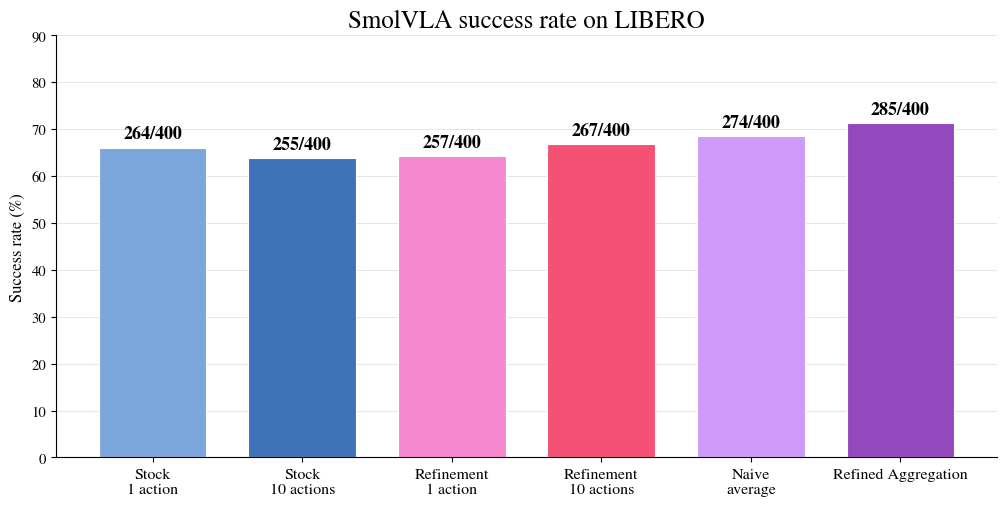

In [4]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'Nimbus Roman', 'STIXGeneral'],
    'mathtext.fontset': 'stix',
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 18,
    'xtick.labelsize': 11.5, 'ytick.labelsize': 10.5,
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',
})

labels = list(arms)
successes = np.array([int(arms[label].success.sum()) for label in labels])
rates = 100.0 * successes / EXPECTED
# colors = ['#9D9D9D', '#666666', '#7AA6DC', '#3E73B8', '#F2A65A', '#4FAF85']
colors = ['#7AA6DC', '#3E73B8', '#f589cf', '#f55174', '#ce9afc', '#9448bd']

fig, ax = plt.subplots(figsize=(10.2, 5.2))
bars = ax.bar(np.arange(len(labels)), rates, width=0.72, color=colors,
              edgecolor='white', linewidth=0.8)
ax.bar_label(bars, labels=[f'{count}/{EXPECTED}' for count in successes],
             padding=4, fontsize=13, fontweight='semibold')
ax.set_xticks(np.arange(len(labels)), labels)
ax.set_ylabel('Success rate (%)')
ax.set_title('SmolVLA success rate on LIBERO')
ax.set_ylim(0, 90)
ax.grid(axis='y', color='#D9D9D9', linewidth=0.8, alpha=0.65)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
for extension in ('png', 'pdf', 'svg'):
    kwargs = {'dpi': 300} if extension == 'png' else {}
    fig.savefig(OUTPUT / f'smolvla_main_sr_400.{extension}',
                bbox_inches='tight', **kwargs)
plt.show()

## Per-suite success rate

,arm,suite,episodes,successes,success_rate_pct
0,Stock\n10 actions,libero_spatial,100,61,61.0
1,Stock\n10 actions,libero_object,100,86,86.0
2,Stock\n10 actions,libero_goal,100,72,72.0
3,Stock\n10 actions,libero_10,100,36,36.0
4,Refinement\n10 actions,libero_spatial,100,67,67.0
5,Refinement\n10 actions,libero_object,100,85,85.0
6,Refinement\n10 actions,libero_goal,100,75,75.0
7,Refinement\n10 actions,libero_10,100,40,40.0
8,Refined Aggregation,libero_spatial,100,73,73.0
9,Refined Aggregation,libero_object,100,87,87.0


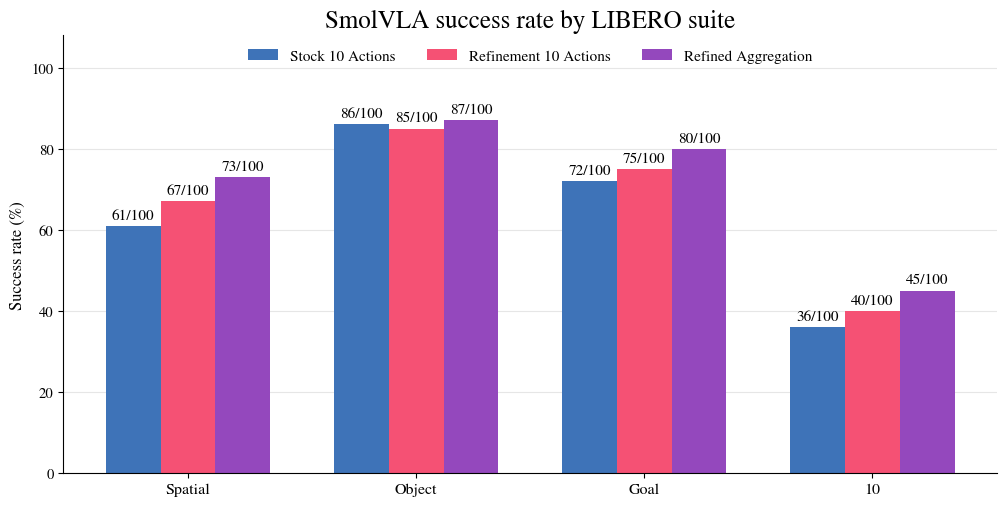

In [5]:
SUITE_ORDER = ['libero_spatial', 'libero_object', 'libero_goal', 'libero_10']
SUITE_LABELS = {
    'libero_spatial': 'Spatial', 'libero_object': 'Object',
    'libero_goal': 'Goal', 'libero_10': '10',
}
STOCK_A10 = 'Stock\n10 actions'
REFINE_A10 = 'Refinement\n10 actions'
BLEND_S03 = 'Refined Aggregation'
SUITE_ARM_LABELS = {
    STOCK_A10: 'Stock 10 Actions',
    REFINE_A10: 'Refinement 10 Actions',
    BLEND_S03: 'Refined Aggregation',
}
SUITE_ARM_COLORS = {
    STOCK_A10: '#3E73B8', REFINE_A10: '#f55174', BLEND_S03: '#9448bd',
}

suite_rows = []
for arm in SUITE_ARM_LABELS:
    for suite in SUITE_ORDER:
        group = arms[arm][arms[arm].suite.eq(suite)]
        if len(group) != 100:
            raise ValueError(f'{arm}/{suite}: expected 100 episodes, found {len(group)}')
        suite_rows.append({
            'arm': arm, 'suite': suite, 'episodes': len(group),
            'successes': int(group.success.sum()),
            'success_rate_pct': 100.0 * group.success.mean(),
        })
suite_success = pd.DataFrame(suite_rows)
suite_success.to_csv(OUTPUT / 'main_sr_by_suite.csv', index=False)
display(suite_success)

x = np.arange(len(SUITE_ORDER)); width = 0.24
fig, ax = plt.subplots(figsize=(10.2, 5.2))
for offset, arm in zip((-width, 0, width), SUITE_ARM_LABELS):
    group = suite_success[suite_success.arm.eq(arm)].set_index('suite').reindex(SUITE_ORDER)
    bars = ax.bar(
        x + offset, group.success_rate_pct, width,
        color=SUITE_ARM_COLORS[arm], label=SUITE_ARM_LABELS[arm])
    ax.bar_label(bars, labels=[f'{value}/100' for value in group.successes],
                 padding=3, fontsize=11, rotation=0)
ax.set_xticks(x, [SUITE_LABELS[suite] for suite in SUITE_ORDER])
ax.set(ylabel='Success rate (%)', ylim=(0, 108))
ax.set_title('SmolVLA success rate by LIBERO suite', fontsize = 18)
ax.legend(frameon=False, ncol=3, loc='upper center')
ax.grid(axis='y', color='#D9D9D9', linewidth=0.8, alpha=0.65)
ax.set_axisbelow(True); ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
for extension in ('png', 'pdf', 'svg'):
    kwargs = {'dpi': 300} if extension == 'png' else {}
    fig.savefig(OUTPUT / f'smolvla_sr_by_suite.{extension}',
                bbox_inches='tight', **kwargs)
plt.show()

## Per-suite outcome transitions from stock $E=10$

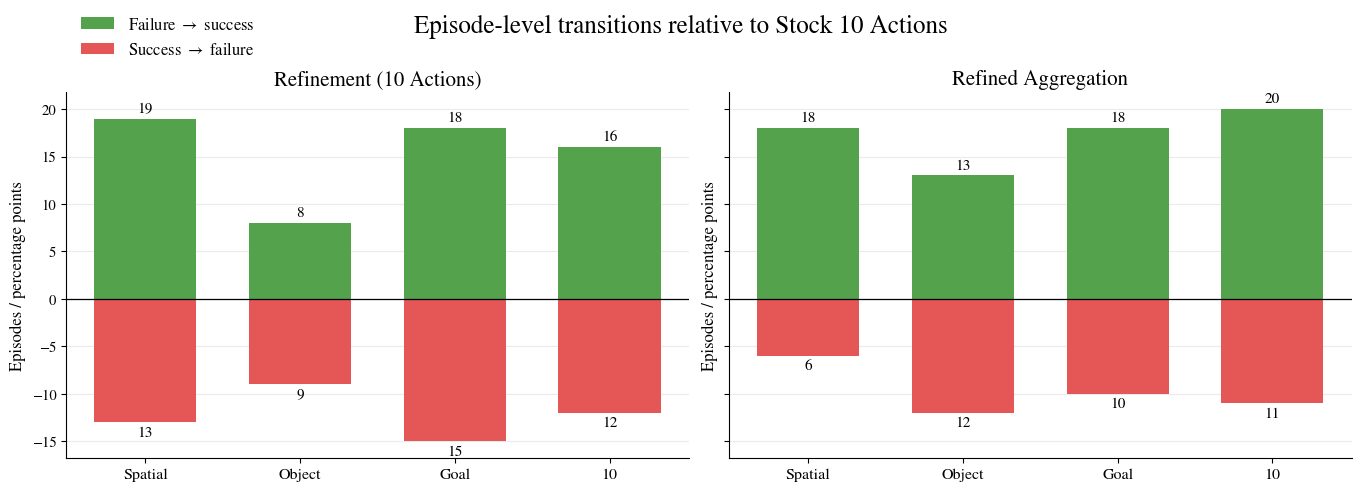

In [23]:
def transition_table(reference, candidate, method_label):
    paired = reference[DIVERSITY_PAIR_KEYS + ['success']].merge(
        candidate[DIVERSITY_PAIR_KEYS + ['success']],
        on=DIVERSITY_PAIR_KEYS, validate='one_to_one',
        suffixes=('_stock', '_candidate'))
    rows = []
    for suite, group in paired.groupby('suite', sort=False):
        stock = group.success_stock.astype(bool)
        condition = group.success_candidate.astype(bool)
        rows.append({
            'method': method_label, 'suite': suite, 'episodes': len(group),
            'failure_to_success': int((~stock & condition).sum()),
            'success_to_failure': int((stock & ~condition).sum()),
            'delta_pp': 100.0 * (condition.mean() - stock.mean()),
        })
    stock = paired.success_stock.astype(bool)
    condition = paired.success_candidate.astype(bool)
    rows.append({
        'method': method_label, 'suite': 'OVERALL', 'episodes': len(paired),
        'failure_to_success': int((~stock & condition).sum()),
        'success_to_failure': int((stock & ~condition).sum()),
        'delta_pp': 100.0 * (condition.mean() - stock.mean()),
    })
    return pd.DataFrame(rows)

transitions = pd.concat([
    transition_table(arms[STOCK_A10], arms[REFINE_A10],
                     'Refinement 10 Actions'),
    transition_table(arms[STOCK_A10], arms[BLEND_S03],
                     'Refined Aggregation'),
], ignore_index=True)
transitions.to_csv(
    OUTPUT / 'main_outcome_transitions_by_suite.csv', index=False)
display(transitions)

plt.close('all')

method_titles = {
    'Refinement 10 Actions': 'Refinement (10 Actions)',
    'Refined Aggregation': 'Refined Aggregation',
}

fig, axes = plt.subplots(
    1, 2,
    figsize=(13.5, 4.8),
    sharey=True,
    constrained_layout=True,
)

for ax, (method_key, method_title) in zip(axes, method_titles.items()):
    group = (
        transitions[
            transitions.method.eq(method_key)
            & transitions.suite.ne('OVERALL')
        ]
        .set_index('suite')
        .reindex(SUITE_ORDER)
    )

    required = [
        'failure_to_success',
        'success_to_failure',
        'delta_pp',
    ]
    if group[required].isna().any().any():
        raise ValueError(f'Missing transition rows for {method_key}')

    rescued = group.failure_to_success.to_numpy(dtype=int)
    harmed = -group.success_to_failure.to_numpy(dtype=int)
    net = group.delta_pp.to_numpy(dtype=float)

    ax.bar(
        x,
        rescued,
        color='#54A24B',
        width=0.66,
        label=r'Failure $\rightarrow$ success',
    )
    ax.bar(
        x,
        harmed,
        color='#E45756',
        width=0.66,
        label=r'Success $\rightarrow$ failure',
    )
    # ax.plot(
    #     x,
    #     net,
    #     color='black',
    #     marker='D',
    #     linewidth=1.3,
    #     markersize=5,
    #     label='Net SR change (pp)',
    # )

    for index, value in enumerate(rescued):
        if value:
            ax.text(
                index,
                value + 0.35,
                str(value),
                ha='center',
                va='bottom',
                fontsize=11,
            )

    for index, value in enumerate(harmed):
        if value:
            ax.text(
                index,
                value - 0.35,
                str(-value),
                ha='center',
                va='top',
                fontsize=11,
            )

    ax.axhline(0, color='black', linewidth=0.9)
    ax.set_xticks(
        x,
        [SUITE_LABELS[suite] for suite in SUITE_ORDER],
        rotation=0,
    )
    ax.set_ylabel('Episodes / percentage points')
    ax.set_title(method_title, fontsize=15)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

# axes[0].legend(frameon=False, fontsize=9, loc='best')
axes[0].legend(
    frameon=False,
    fontsize=12,
    loc='upper left',
    bbox_to_anchor=(0.0, 1.25),
)

fig.suptitle(
    'Episode-level transitions relative to Stock 10 Actions',
    fontsize=18,
    y=0.98
)

for extension in ('png', 'pdf', 'svg'):
    kwargs = {'dpi': 300} if extension == 'png' else {}
    fig.savefig(
        OUTPUT / f'smolvla_transitions_by_suite.{extension}',
        bbox_inches='tight',
        **kwargs,
    )

plt.show()

## Pair-weighted $U_{10}$ failure ROC-AUC

This reproduces notebook 86's retrospective uncertainty definition for the $E=10$ refinement arm: average the first ten action positions within each chunk, average over all chunks in the completed episode, and weight flow times according to the $(3,1,1)$ number of logged P\&P comparison pairs. Failure is the positive class.

Loaded decoded U10 records from cache.


,suite,score_name,episodes,failures,failure_auc,auc_ci_low,auc_ci_high
0,pooled,u10_weighted_episode,400,133,0.850835,0.809487,0.888037
1,libero_10,u10_weighted_episode,100,60,0.826250,0.731397,0.904244
2,libero_goal,u10_weighted_episode,100,25,0.875200,0.796253,0.938420
3,libero_object,u10_weighted_episode,100,15,0.959216,0.881677,1.000000
4,libero_spatial,u10_weighted_episode,100,33,0.859340,0.762467,0.937358


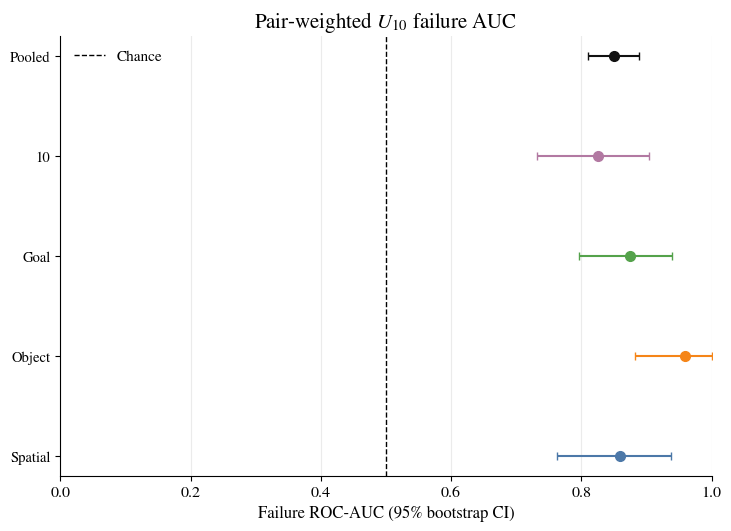

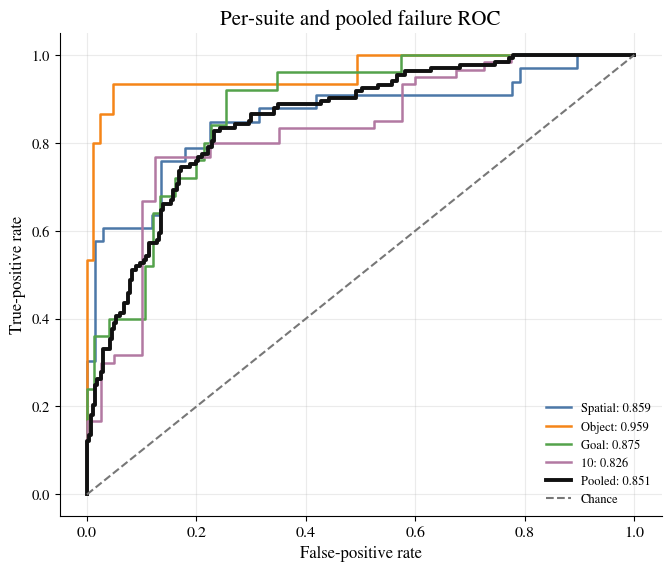

In [24]:
import io
import re
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve

from analysis.horizon_diagnostics import failure_auc_table, _download_with_retry
from pnp.smolvla_followup_experiments import (
    SMOLVLA_SCHEDULE_K_BY_STEP, SMOLVLA_SCHEDULE_STEPS)

N_BOOT = 3000
KEY = re.compile(r'^c(?P<chunk>\d+)_s(?P<step>\d+)_u_time$')
refinement_rows = arms[REFINE_A10].copy()
if refinement_rows.ahats_path.isna().any():
    raise ValueError('E=10 refinement rows are missing uncertainty artifacts')
refinement_hash = provenance[provenance.label.eq('Refinement 10 actions')].config_hash.iloc[0]
cache_file = OUTPUT / f'u10_step_records_{refinement_hash[:12]}.pkl'

if cache_file.exists():
    u10_records = pd.read_pickle(cache_file)
    print('Loaded decoded U10 records from cache.')
else:
    decoded = []
    expected_pairs = dict(zip(SMOLVLA_SCHEDULE_STEPS, SMOLVLA_SCHEDULE_K_BY_STEP))
    for row in tqdm(refinement_rows.to_dict('records'), desc='refinement U10 artifacts'):
        payload = _download_with_retry(store, str(row['ahats_path']))
        with np.load(io.BytesIO(payload)) as archive:
            for key in archive.files:
                match = KEY.match(key)
                if not match:
                    continue
                step = int(match.group('step'))
                if step not in expected_pairs:
                    continue
                profile = np.asarray(archive[key], dtype=float).reshape(-1)
                iter_key = key.removesuffix('_u_time') + '_u_iter_time'
                pair_profile = np.asarray(archive[iter_key], dtype=float)
                if len(profile) != 50 or pair_profile.shape != (expected_pairs[step], 50):
                    raise ValueError(
                        f'{row["rollout_id"]}/{key}: malformed uncertainty artifact')
                decoded.append({
                    'rollout_id': row['rollout_id'], 'suite': row['suite'],
                    'success': bool(row['success']),
                    'chunk_idx': int(match.group('chunk')), 'flow_step': step,
                    'u10': float(profile[:10].mean()),
                })
    u10_records = pd.DataFrame(decoded)
    u10_records.to_pickle(cache_file)

observed_steps = tuple(sorted(u10_records.flow_step.unique()))
if observed_steps != tuple(SMOLVLA_SCHEDULE_STEPS):
    raise ValueError(f'expected flow steps {SMOLVLA_SCHEDULE_STEPS}, found {observed_steps}')
step_counts = u10_records.groupby(['rollout_id', 'chunk_idx']).flow_step.nunique()
if not step_counts.eq(len(SMOLVLA_SCHEDULE_STEPS)).all():
    raise ValueError('at least one action chunk is missing a probed flow time')

per_step = u10_records.groupby(['rollout_id', 'flow_step']).u10.mean().unstack('flow_step')
u10_features = refinement_rows[['rollout_id', 'suite', 'success']].merge(
    per_step, on='rollout_id', validate='one_to_one')
weights = dict(zip(SMOLVLA_SCHEDULE_STEPS, SMOLVLA_SCHEDULE_K_BY_STEP))
weight_sum = sum(weights.values())
u10_features['u10_weighted_episode'] = sum(
    weights[step] * u10_features[step] for step in SMOLVLA_SCHEDULE_STEPS
) / weight_sum
if len(u10_features) != EXPECTED:
    raise ValueError(f'expected {EXPECTED} U10 episodes, found {len(u10_features)}')

u10_auc = failure_auc_table(
    u10_features, ['u10_weighted_episode'], n_boot=N_BOOT)
u10_auc.to_csv(OUTPUT / 'u10_failure_auc_by_suite.csv', index=False)
u10_features.to_csv(OUTPUT / 'u10_episode_scores.csv', index=False)
display(u10_auc)

auc_order = SUITE_ORDER + ['pooled']
auc_labels = [SUITE_LABELS[suite] for suite in SUITE_ORDER] + ['Pooled']
auc_colors = ['#4C78A8', '#F58518', '#54A24B', '#B279A2', '#111111']

auc_indexed = u10_auc.set_index('suite').reindex(auc_order)
auc_lookup = u10_auc.set_index('suite').failure_auc


# ------------------------------------------------------------
# Figure 1: Per-suite and pooled AUC with confidence intervals
# ------------------------------------------------------------

fig_auc, ax_auc = plt.subplots(
    figsize=(7.2, 5.2),
    constrained_layout=True,
)

for position, (suite, label, color) in enumerate(
    zip(auc_order, auc_labels, auc_colors)
):
    row = auc_indexed.loc[suite]

    ax_auc.errorbar(
        row.failure_auc,
        position,
        xerr=[
            [row.failure_auc - row.auc_ci_low],
            [row.auc_ci_high - row.failure_auc],
        ],
        fmt='o',
        color=color,
        capsize=3,
        markersize=7,
    )

ax_auc.set_yticks(
    np.arange(len(auc_order)),
    auc_labels,
)
ax_auc.axvline(
    0.5,
    color='black',
    linestyle='--',
    linewidth=1,
    label='Chance',
)
ax_auc.set_xlim(0, 1)
ax_auc.set_xlabel('Failure ROC-AUC (95% bootstrap CI)')
ax_auc.set_title(
    r'Pair-weighted $U_{10}$ failure AUC',
    fontsize=15,
)
ax_auc.grid(axis='x', alpha=0.25)
ax_auc.legend(frameon=False)
ax_auc.spines[['top', 'right']].set_visible(False)

for extension in ('png', 'pdf', 'svg'):
    kwargs = {'dpi': 300} if extension == 'png' else {}
    fig_auc.savefig(
        OUTPUT / f'smolvla_u10_failure_auc_by_suite.{extension}',
        bbox_inches='tight',
        **kwargs,
    )

plt.show()


# ------------------------------------------------------------
# Figure 2: Per-suite and pooled ROC curves
# ------------------------------------------------------------

fig_roc, ax_roc = plt.subplots(
    figsize=(6.6, 5.6),
    constrained_layout=True,
)

for suite, label, color in zip(
    SUITE_ORDER,
    auc_labels[:-1],
    auc_colors[:-1],
):
    group = u10_features[u10_features.suite.eq(suite)]
    failure = ~group.success.astype(bool).to_numpy()

    fpr, tpr, _ = roc_curve(
        failure,
        group.u10_weighted_episode.to_numpy(float),
    )

    ax_roc.plot(
        fpr,
        tpr,
        color=color,
        linewidth=1.8,
        label=f'{label}: {auc_lookup.loc[suite]:.3f}',
    )

failure = ~u10_features.success.astype(bool).to_numpy()
fpr, tpr, _ = roc_curve(
    failure,
    u10_features.u10_weighted_episode.to_numpy(float),
)

ax_roc.plot(
    fpr,
    tpr,
    color='#111111',
    linewidth=2.8,
    label=f'Pooled: {auc_lookup.loc["pooled"]:.3f}',
)
ax_roc.plot(
    [0, 1],
    [0, 1],
    color='#777777',
    linestyle='--',
    label='Chance',
)

ax_roc.set_xlabel('False-positive rate')
ax_roc.set_ylabel('True-positive rate')
ax_roc.set_title(
    'Per-suite and pooled failure ROC',
    fontsize=15,
)
ax_roc.grid(alpha=0.25)
ax_roc.legend(frameon=False, fontsize=9)
ax_roc.spines[['top', 'right']].set_visible(False)

for extension in ('png', 'pdf', 'svg'):
    kwargs = {'dpi': 300} if extension == 'png' else {}
    fig_roc.savefig(
        OUTPUT / f'smolvla_u10_failure_roc.{extension}',
        bbox_inches='tight',
        **kwargs,
    )

plt.show()

All paper figures are exported as PNG, PDF, and SVG under `paper_figures_smolvla/`; the corresponding counts, transition tables, AUC values, and provenance are exported as CSV files.